# Machine Learning - Online News Popularity Prediction

## Objective
Build models to predict article popularity using log-transformed shares.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv('../data/processed/cleaned_online_news.csv')
df.head()

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,log_shares
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593,6.386879
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711,6.568078
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500,7.313887
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200,7.090910
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505,6.226537


In [3]:
# Define features and target variable
X = df.drop(columns=["shares", "log_shares"])
y = df["log_shares"]

In [4]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# Baseline Model: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 0.8648576034705296
Linear Regression R2: 0.1274222678511584


In [6]:
# Advanced Model: Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 0.8485579781903964
Random Forest R2: 0.16000258010201152


In [7]:
# Compare Models
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [rmse_lr, rmse_rf],
    "R2 Score": [r2_lr, r2_rf]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,0.864858,0.127422
1,Random Forest,0.848558,0.160003


In [8]:
# Feature Importance
importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
25,kw_avg_avg,0.193006
28,self_reference_avg_sharess,0.066268
24,kw_max_avg,0.048422
26,self_reference_min_shares,0.042734
22,kw_avg_max,0.027311
5,num_hrefs,0.026631
2,n_unique_tokens,0.026505
38,LDA_01,0.026212
42,global_subjectivity,0.025028
4,n_non_stop_unique_tokens,0.024509


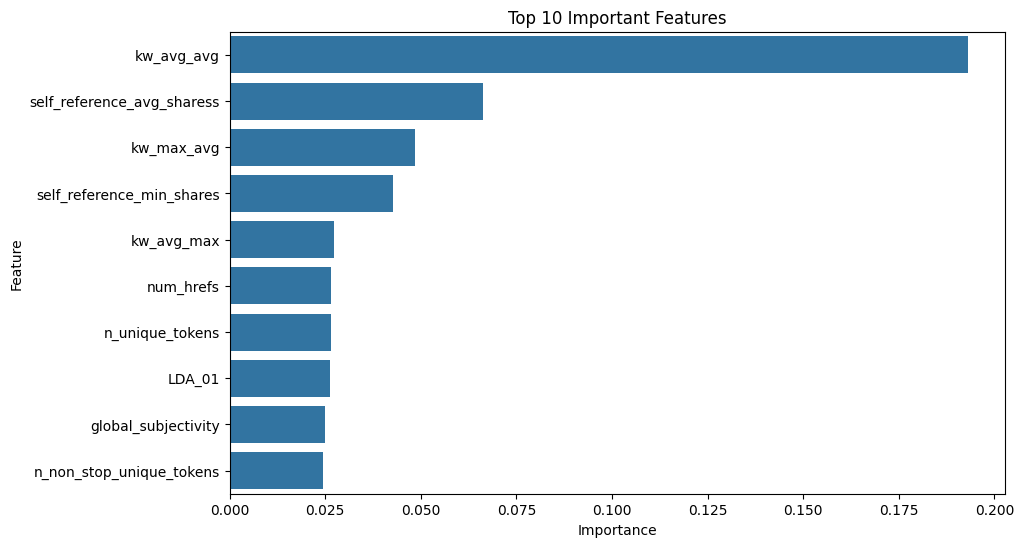

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance_df.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Important Features")
plt.show()

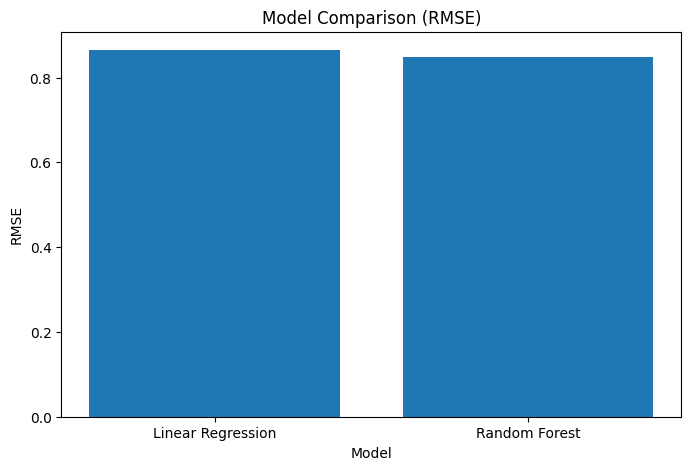

In [14]:
models = ["Linear Regression", "Random Forest"]
rmse = [rmse_lr, rmse_rf]
r2 = [r2_lr, r2_rf]

x = range(len(models))

plt.figure(figsize=(8,5))
plt.bar(x, rmse)
plt.xticks(x, models)
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xlabel("Model")

plt.savefig("../images/model_comparison.png")
plt.show()

In [12]:
import joblib

joblib.dump(rf, "../src/random_forest_model.pkl")

['../src/random_forest_model.pkl']